# 모델 선정 — Adult Census Income

전처리(dropna) 데이터셋을 대상으로 **5개 분류 모델을 동일한 조건에서 비교**하고
최종 모델 1개를 선정한다.

| 항목 | 값 |
|---|---|
| 데이터 | `data/adult_train_dropna.csv` (30,162행) / `data/adult_test_dropna.csv` (15,060행) |
| 타깃 | `income` — 양성 클래스 `>50K` |
| 후보 모델 | LogisticRegression, RandomForest, SVC(RBF), MLP, XGBoost |
| 공통 시드 | `20260807` (팀 리포트 규약) |

## 실험 프로토콜 (통일 사항)

기존 개별 실험 스크립트(`notebooks/legacy/`)는 시드·피처셋·전처리·지표가 서로 달라
그대로는 비교표를 만들 수 없었다. 아래 4가지를 통일해 **모델만 다른** 상태로 맞춘다.

1. **시드** — 전부 `20260807`. (기존: LR/RF/XGB `42`, NN `20260807`, SVC 미지정)
2. **피처셋** — `fnlwgt` **제외**. 표본가중치라 예측 변수로 부적합하다.
   (기존: LR/RF/XGB는 포함, NN/SVC는 제외)
3. **전처리** — 수치형 `StandardScaler` + 범주형 `OneHotEncoder(handle_unknown="ignore")`
   단일 `ColumnTransformer`를 **모든 모델이 공유**한다. dropna 데이터이므로 결측 대체 단계는 없다.
   (기존: LR만 스케일링, XGB는 원핫 대신 `enable_categorical`)
4. **지표** — accuracy / precision / recall / f1 / ROC-AUC / balanced accuracy + 학습 시간.
   (기존: SVC만 ROC-AUC 없음)

> **실행 시간** — 5개 모델 전체 학습에 20초 내외가 걸린다(측정값 기준).
> SVC(RBF)가 그중 절반 이상을 차지하므로, 재실행 시 가장 오래 기다리게 되는 구간이다.

## 1. 공통 설정

In [1]:
from __future__ import annotations

import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=UserWarning)

# 노트북은 독립 실행형이므로 config.py를 import하지 않고 상수를 직접 정의한다.
SEED = 20260807

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODEL_DIR = OUTPUT_DIR / "models"

TRAIN_PATH = DATA_DIR / "adult_train_dropna.csv"
TEST_PATH = DATA_DIR / "adult_test_dropna.csv"

TARGET = "income"
POSITIVE_LABEL = ">50K"

# fnlwgt는 표본가중치이므로 예측 변수에서 제외한다.
NUM_COLS = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
CAT_COLS = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
]
FEATURE_COLS = NUM_COLS + CAT_COLS

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# 그래프 제목·라벨이 한글이라 폰트를 지정하지 않으면 네모(tofu)로 깨진다.
for _font in ["AppleGothic", "NanumGothic", "Malgun Gothic"]:
    if any(f.name == _font for f in font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = _font
        break
plt.rcParams["axes.unicode_minus"] = False  # 한글 폰트 사용 시 음수 부호 깨짐 방지

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"피처 {len(FEATURE_COLS)}개 (수치 {len(NUM_COLS)} / 범주 {len(CAT_COLS)}), 시드 {SEED}")

PROJECT_ROOT = /Users/donghyeon/skala-workspace/week4/team-analysis
피처 13개 (수치 5 / 범주 8), 시드 20260807


## 2. 데이터 로딩 및 스키마 검증

경로가 없거나 필요한 컬럼이 빠졌으면 여기서 즉시 실패시킨다.
아래 셀만 통과하면 이후 셀은 데이터 형태를 다시 방어하지 않는다.

In [2]:
def load_split(path: Path) -> pd.DataFrame:
    """CSV를 읽고 필요한 컬럼이 모두 있는지 검증한다."""
    try:
        df = pd.read_csv(path)
    except FileNotFoundError as exc:
        raise FileNotFoundError(
            f"{path} 를 찾을 수 없습니다. 전처리 노트북(preprocessing.ipynb)을 먼저 실행하세요."
        ) from exc
    except pd.errors.ParserError as exc:
        raise ValueError(f"{path} 파싱 실패: {exc}") from exc

    missing = [c for c in [*FEATURE_COLS, TARGET] if c not in df.columns]
    if missing:
        raise KeyError(f"{path.name} 에 필요한 컬럼이 없습니다: {missing}")
    if df.empty:
        raise ValueError(f"{path.name} 이 비어 있습니다.")
    return df


train_df = load_split(TRAIN_PATH)
test_df = load_split(TEST_PATH)

X_train, y_train = train_df[FEATURE_COLS], (train_df[TARGET] == POSITIVE_LABEL).astype(int)
X_test, y_test = test_df[FEATURE_COLS], (test_df[TARGET] == POSITIVE_LABEL).astype(int)

print(f"train {X_train.shape}  positive rate = {y_train.mean():.4f}")
print(f"test  {X_test.shape}  positive rate = {y_test.mean():.4f}")
display(train_df[[*NUM_COLS, TARGET]].describe().T)

train (30162, 13)  positive rate = 0.2489
test  (15060, 13)  positive rate = 0.2457


,count,mean,std,min,25%,50%,75%,max
age,30162.0,38.437902,13.134665,17.0,28.0,37.0,47.0,90.0
education-num,30162.0,10.121312,2.549995,1.0,9.0,10.0,13.0,16.0
capital-gain,30162.0,1092.007858,7406.346497,0.0,0.0,0.0,0.0,99999.0
capital-loss,30162.0,88.372489,404.298370,0.0,0.0,0.0,0.0,4356.0
hours-per-week,30162.0,40.931238,11.979984,1.0,40.0,40.0,45.0,99.0


## 3. 공통 전처리기

모델별 `Pipeline`은 **마지막 스텝만** 교체한다. 전처리는 매번 같은 함수로 새로 만들어
모델 간에 `fit` 상태가 공유되지 않게 한다.

In [3]:
def build_preprocessor() -> ColumnTransformer:
    """수치형 표준화 + 범주형 원핫 인코딩. 모든 후보 모델이 동일하게 사용한다."""
    return ColumnTransformer(
        [
            ("num", StandardScaler(), NUM_COLS),
            ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
        ]
    )


_n_features = build_preprocessor().fit_transform(X_train).shape[1]
print(f"원핫 확장 후 피처 수: {_n_features}")

원핫 확장 후 피처 수: 103


## 4. 후보 모델 정의

하이퍼파라미터는 `notebooks/legacy/` 의 각 실험 스크립트에서 그대로 가져왔고,
`random_state`만 공통 시드로 통일했다.

SVC는 `probability=True`(내부 5-fold Platt 스케일링)를 켜면 학습이 몇 배 느려지므로,
확률 대신 `decision_function` 점수로 ROC-AUC를 계산한다 — AUC는 순위 기반 지표라
단조 변환에 불변이므로 확률로 계산한 값과 동일하다.

In [4]:
def build_models() -> dict[str, object]:
    """모델명 → 미학습 분류기. 하이퍼파라미터는 legacy 실험 스크립트 기준."""
    return {
        "LogisticRegression": LogisticRegression(
            max_iter=5000, solver="saga", random_state=SEED
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=250, random_state=SEED, n_jobs=-1
        ),
        "SVC(RBF)": SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED),
        "MLP": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            early_stopping=True,
            n_iter_no_change=10,
            max_iter=300,
            random_state=SEED,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=5,
            min_child_weight=3,
            subsample=0.9,
            colsample_bytree=0.8,
            reg_lambda=1.5,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=SEED,
            n_jobs=-1,
        ),
    }


print(" / ".join(build_models()))

LogisticRegression / RandomForest / SVC(RBF) / MLP / XGBoost


## 5. 평가 프로토콜

In [5]:
def rank_scores(pipeline: Pipeline, X: pd.DataFrame) -> np.ndarray:
    """ROC-AUC용 양성 점수. predict_proba가 없으면 decision_function으로 대체한다."""
    if hasattr(pipeline, "predict_proba"):
        return pipeline.predict_proba(X)[:, 1]
    return pipeline.decision_function(X)


def evaluate(name: str, model: object) -> tuple[dict[str, float], Pipeline, np.ndarray]:
    """모델 하나를 학습·평가해 (지표, 학습된 파이프라인, 양성 점수)를 돌려준다."""
    pipeline = Pipeline([("preprocess", build_preprocessor()), ("model", model)])

    started = time.perf_counter()
    pipeline.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - started

    y_pred = pipeline.predict(X_test)
    y_score = rank_scores(pipeline, X_test)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_acc": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "fit_sec": fit_seconds,
    }
    return metrics, pipeline, y_score

## 6. 학습 및 평가 실행

**이 셀이 가장 오래 걸린다.** SVC(RBF)가 대부분의 시간을 차지한다.

In [6]:
results: list[dict[str, float]] = []
fitted: dict[str, Pipeline] = {}
scores: dict[str, np.ndarray] = {}

for name, model in build_models().items():
    print(f"[학습 중] {name} ...", flush=True)
    try:
        metrics, pipeline, y_score = evaluate(name, model)
    except (ValueError, MemoryError) as exc:
        # 한 모델이 실패해도 나머지 비교는 계속한다.
        print(f"  ! {name} 실패: {exc}")
        continue
    results.append(metrics)
    fitted[name] = pipeline
    scores[name] = y_score
    print(
        f"  완료 — f1={metrics['f1']:.4f}"
        f"  auc={metrics['roc_auc']:.4f}  ({metrics['fit_sec']:.1f}s)"
    )

if not results:
    raise RuntimeError("모든 모델이 실패했습니다. 위 오류 메시지를 확인하세요.")

[학습 중] LogisticRegression ...


  완료 — f1=0.6585  auc=0.9030  (0.7s)
[학습 중] RandomForest ...


  완료 — f1=0.6540  auc=0.8881  (2.5s)
[학습 중] SVC(RBF) ...


  완료 — f1=0.6677  auc=0.8977  (10.3s)
[학습 중] MLP ...


  완료 — f1=0.6781  auc=0.9040  (1.5s)
[학습 중] XGBoost ...


  완료 — f1=0.7133  auc=0.9270  (0.5s)


## 7. 비교표

선정 기준은 **F1**을 주 지표로 둔다. 양성 클래스(`>50K`)가 약 25%인 불균형 데이터라
accuracy는 모든 모델을 다수 클래스 쪽으로 비슷하게 보이게 만들어 변별력이 떨어진다.
ROC-AUC는 임계값과 무관한 순위 품질을 보는 보조 지표로 함께 본다.

In [7]:
PRIMARY_METRIC = "f1"

results_df = (
    pd.DataFrame(results)
    .set_index("model")
    .sort_values(PRIMARY_METRIC, ascending=False)
    .round(4)
)
display(results_df)

,accuracy,balanced_acc,precision,recall,f1,roc_auc,fit_sec
model,,,,,,,
XGBoost,0.8695,0.7992,0.7750,0.6608,0.7133,0.9270,0.5071
MLP,0.8446,0.7845,0.6905,0.6662,0.6781,0.9040,1.4768
SVC(RBF),0.8538,0.7675,0.7560,0.5978,0.6677,0.8977,10.2647
LogisticRegression,0.8471,0.7638,0.7295,0.6000,0.6585,0.9030,0.6781
RandomForest,0.8392,0.7648,0.6936,0.6186,0.6540,0.8881,2.5299


## 8. 시각화

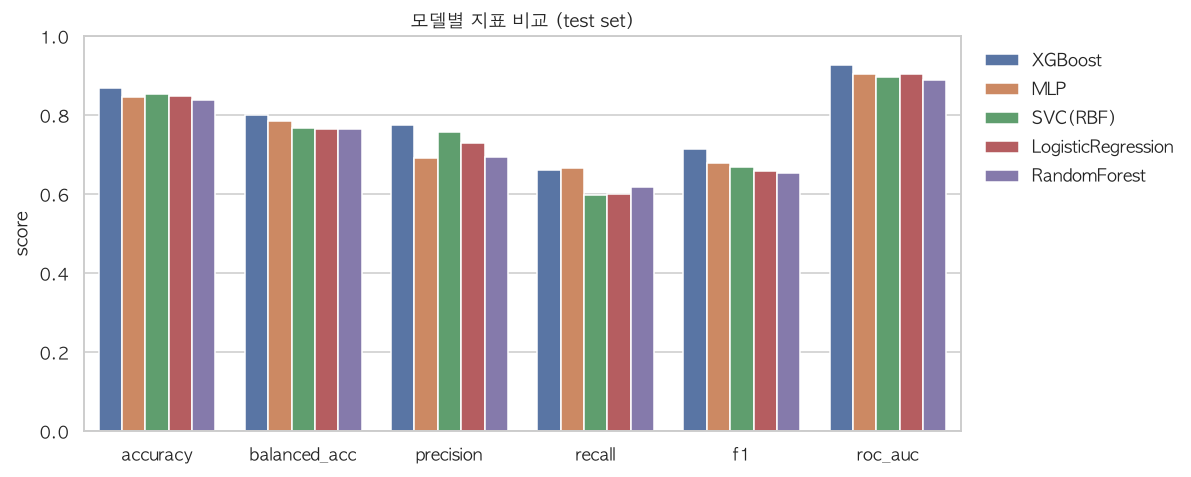

In [8]:
plot_metrics = ["accuracy", "balanced_acc", "precision", "recall", "f1", "roc_auc"]
long_df = results_df[plot_metrics].reset_index().melt(
    id_vars="model", var_name="metric", value_name="score"
)

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(data=long_df, x="metric", y="score", hue="model", ax=ax)
ax.set_title("모델별 지표 비교 (test set)")
ax.set_ylim(0, 1.0)
ax.set_xlabel("")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

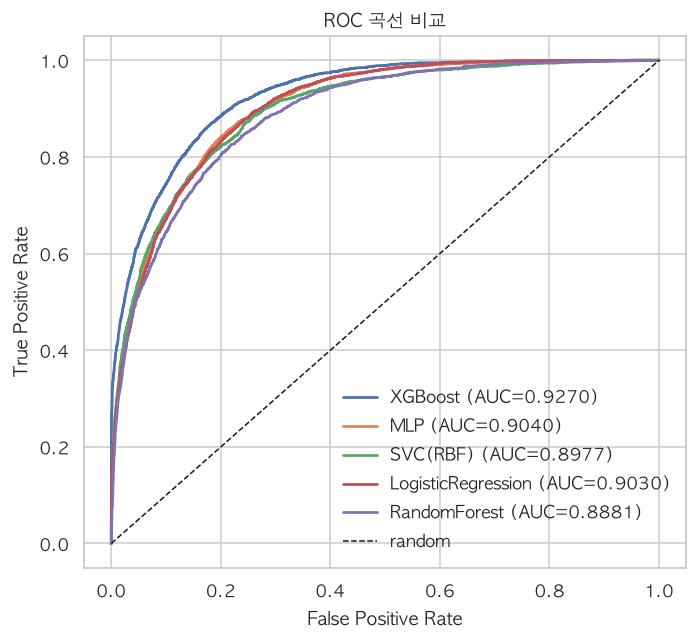

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for name in results_df.index:
    fpr, tpr, _ = roc_curve(y_test, scores[name])
    ax.plot(fpr, tpr, lw=1.8, label=f"{name} (AUC={results_df.loc[name, 'roc_auc']:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC 곡선 비교")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

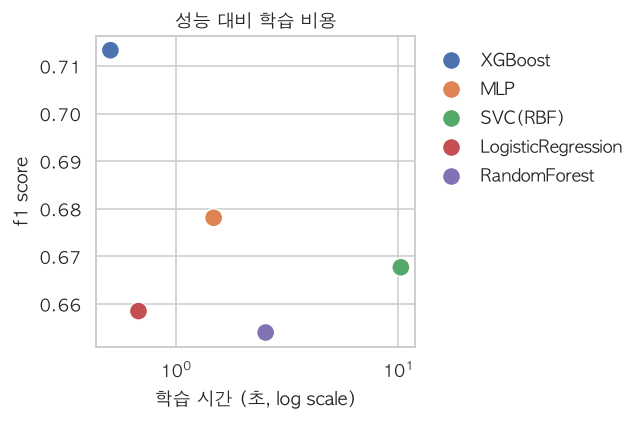

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(
    data=results_df.reset_index(), x="fit_sec", y=PRIMARY_METRIC, hue="model", s=140, ax=ax
)
ax.set_xscale("log")
ax.set_xlabel("학습 시간 (초, log scale)")
ax.set_ylabel(f"{PRIMARY_METRIC} score")
ax.set_title("성능 대비 학습 비용")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

## 9. 최종 모델 선정

In [11]:
best_name = str(results_df[PRIMARY_METRIC].idxmax())
best_row = results_df.loc[best_name]
best_pipeline = fitted[best_name]

print(f"선정 모델: {best_name}")
print(f"  f1           = {best_row['f1']:.4f}")
print(f"  roc_auc      = {best_row['roc_auc']:.4f}")
print(f"  accuracy     = {best_row['accuracy']:.4f}")
print(f"  balanced_acc = {best_row['balanced_acc']:.4f}")
print(f"  학습 시간    = {best_row['fit_sec']:.1f}s")
print()
print(classification_report(y_test, best_pipeline.predict(X_test), target_names=["<=50K", ">50K"]))

선정 모델: XGBoost
  f1           = 0.7133
  roc_auc      = 0.9270
  accuracy     = 0.8695
  balanced_acc = 0.7992
  학습 시간    = 0.5s

              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.92     11360
        >50K       0.77      0.66      0.71      3700

    accuracy                           0.87     15060
   macro avg       0.83      0.80      0.81     15060
weighted avg       0.87      0.87      0.87     15060



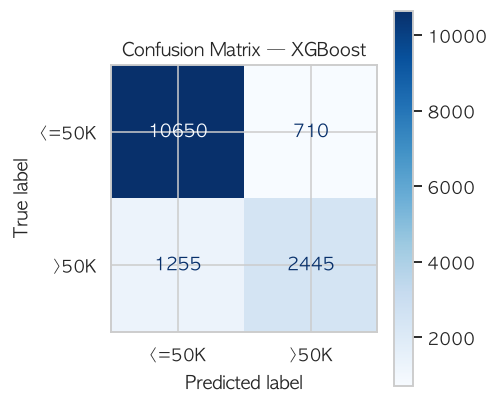

In [12]:
fig, ax = plt.subplots(figsize=(4.6, 4.2))
ConfusionMatrixDisplay.from_estimator(
    best_pipeline, X_test, y_test, display_labels=["<=50K", ">50K"], cmap="Blues", ax=ax
)
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

## 10. 모델 저장 및 재로드 검증

저장한 파일을 다시 읽어 예측이 완전히 일치하는지 확인한다.
직렬화가 깨진 모델을 리포트 단계로 넘기지 않기 위한 안전장치다.

In [13]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODEL_DIR / "adult_income_selected_pipeline.joblib"
metrics_path = OUTPUT_DIR / "model_selection_results.csv"

try:
    joblib.dump(best_pipeline, model_path)
    results_df.to_csv(metrics_path)
except OSError as exc:
    raise OSError(f"산출물 저장 실패: {exc}") from exc

reloaded = joblib.load(model_path)
assert np.array_equal(reloaded.predict(X_test), best_pipeline.predict(X_test)), (
    "재로드한 모델의 예측이 원본과 다릅니다."
)

print(f"모델 저장   : {model_path}")
print(f"지표표 저장 : {metrics_path}")
print("재로드 예측 일치 확인 완료")

모델 저장   : /Users/donghyeon/skala-workspace/week4/team-analysis/outputs/models/adult_income_selected_pipeline.joblib
지표표 저장 : /Users/donghyeon/skala-workspace/week4/team-analysis/outputs/model_selection_results.csv
재로드 예측 일치 확인 완료


## 11. 결론

- 위 표는 **시드·피처셋·전처리·지표를 모두 통일한** 상태의 비교 결과다.
  개별 실험 스크립트의 기존 수치와는 다를 수 있으며, 비교 가능한 쪽은 이 표다.
- 선정 모델과 지표표는 `outputs/` 아래에 저장되어 리포트 생성 단계에서 재사용한다.
- 원본 실험 스크립트는 `notebooks/legacy/` 에 보존되어 있다.

### 후속 과제
- 하이퍼파라미터는 legacy 스크립트의 수동 설정값이다. 선정 모델에 대해
  `GridSearchCV` / `RandomizedSearchCV` 로 탐색하면 개선 여지가 있다.
- 단일 train/test 분할 기준이므로, 교차검증으로 지표의 분산까지 보면 더 견고해진다.
- 불균형(양성 약 25%)에 대해 `class_weight` / 임계값 조정을 적용하면 recall을 끌어올릴 수 있다.